<div style="text-align: center; margin-bottom: 10px;">
  <img src="assets/logo.png" width="200">
</div>

<h1 style="text-align: center;">
Risk Routing: Protecting SLAs Through Early Prioritization
</h1>

<h3 style="text-align: center;">
Rank incoming work by cycle-time risk to support proactive operational decisions.
</h3>

<hr style="border: 1px solid #cfd8dc; width: 60%;">

## Business Context
Operational teams often have limited capacity to review incoming work. This analysis explores whether cycle-time risk can be estimated at intake and used to prioritize a small subset of work before delays occur.

## Executive Summary
**Decision Framework**
- Route the **top 10% highest-risk work items** to a priority queue
- Support **instrument rebalancing** and **staffing decisions**
- Protect **service-level targets (SLAs)**

**Model Target**
- Predict risk of falling into the **slowest 10% of cycle times (P90)**
- Compare work within the same **instrument type × test type** group

**Validation Approach**
- **Instrument-held-out GroupKFold cross-validation**
- Evaluate performance on unseen instruments

**Success Metrics**
- **Top-10% routing precision**
- **Late-rate lift**
- **Probability-based risk scores**
- **Operational routing outcomes**

> This notebook uses simulated operational data to demonstrate workflow design, model validation, and decision-support methodology.

## Imports

In [28]:
# --- setup (imports) ---
from __future__ import annotations
from pathlib import Path

import math

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## Utilities

In [29]:
# --- configuration ---
SEED = 42
QUEUE_PCT = 0.10          # route top 10% highest-risk work items
SLA_ROUND_HOURS = 4       # round derived SLA to nearest 4 hours for stakeholder readability
GROUP_COLS = ["instrument_type", "test_type"]
TARGET_COL = "cycle_time_hours"



# --- functions ---
def top_k_precision(y_true: np.ndarray, y_score: np.ndarray, top_frac: float = 0.10) -> float:
    k = max(1, int(math.ceil(len(y_score) * top_frac)))
    idx = np.argsort(-y_score)[:k]
    return float(y_true[idx].mean())


def make_fold_targets(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    group_cols: list[str],
    target_col: str,
    p: float = 0.90,
) -> tuple[pd.Series, pd.Series]:
    # P90 per group from training data only
    p90 = (
        train_df.groupby(group_cols)[target_col]
        .quantile(p)
        .rename("p90")
        .reset_index()
    )

    train = train_df.merge(p90, on=group_cols, how="left")
    test = test_df.merge(p90, on=group_cols, how="left")

    # If a group appears only in test (rare), fall back to global training P90.
    global_p90 = train_df[target_col].quantile(p)
    train["p90"] = train["p90"].fillna(global_p90)
    test["p90"] = test["p90"].fillna(global_p90)

    y_train = (train[target_col] > train["p90"]).astype(int)
    y_test = (test[target_col] > test["p90"]).astype(int)
    return y_train, y_test


def derive_sla_hours(df: pd.DataFrame, group_cols: list[str], target_col: str) -> float:
    group_p90 = df.groupby(group_cols)[target_col].quantile(0.90)
    raw = float(group_p90.median())
    rounded = round(raw / SLA_ROUND_HOURS) * SLA_ROUND_HOURS
    return max(SLA_ROUND_HOURS, float(rounded))


def add_instrument_workload_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Add leakage-safe instrument workload features from prior days.

    Creates instrument-day aggregates and rolling means over 7 and 28 days,
    then merges them back onto the row-level dataset by (instrument_id, day).
    """
    df = df_in.copy()
    df["day"] = df["date"].dt.floor("D")

    # instrument-day aggregates
    g = (
        df.groupby(["instrument_id", "day"], as_index=False)
        .agg(
            runs=("instrument_id", "size"),
            mean_duration=("duration_min", "mean"),
            mean_cycle_time=("cycle_time_hours", "mean"),
        )
        .sort_values(["instrument_id", "day"])
        .reset_index(drop=True)
    )

    # rolling workload features (prior days only: shift(1) avoids leakage)
    for w in (7, 28):
        g[f"runs_roll{w}d"] = (
            g.groupby("instrument_id")["runs"]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )
        g[f"mean_duration_roll{w}d"] = (
            g.groupby("instrument_id")["mean_duration"]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )
        g[f"mean_cycle_time_roll{w}d"] = (
            g.groupby("instrument_id")["mean_cycle_time"]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )

    # merge features back to row-level
    df = df.merge(g, on=["instrument_id", "day"], how="left")

    # calendar features
    df["day_of_week"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month

    return df


## Load data

In [30]:
# --- load data ---
DATA_PATH = Path("data/qc_instrument_usage.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df = df.drop(columns=["downtime_reason"], errors="ignore")

# Domain-friendly naming
df["cycle_time_hours"] = df["turnaround_hours"]


## Data snapshot: what is known at intake

At intake we know:
- instrument assignment (`instrument_id`, `instrument_type`)
- request details (`test_type`, `product_family`)
- routing context (`operator`, `automation_phase`)
- light process signals (`duration_min`, `manual_entry`)

Outcome: **cycle time (hours)** from `turnaround_hours`

In [31]:
# Data snapshot

snapshot = pd.DataFrame(
    {
        "rows": [len(df)],
        "date_min": [df["date"].min().date()],
        "date_max": [df["date"].max().date()],
        "n_instruments": [df["instrument_id"].nunique()],
        "n_instrument_types": [df["instrument_type"].nunique()],
        "n_test_types": [df["test_type"].nunique()],
    }
)
display(snapshot)

preview_cols = [
    "date",
    "instrument_type",
    "test_type",
    "duration_min",
    "manual_entry",
    "cycle_time_hours",
]
display(
    df[preview_cols]
    .sample(6, random_state=SEED)
    .sort_values("date")
    .reset_index(drop=True)
)

,rows,date_min,date_max,n_instruments,n_instrument_types,n_test_types
0,9107,2024-01-01,2024-12-30,6,5,5


,date,instrument_type,test_type,duration_min,manual_entry,cycle_time_hours
0,2024-02-26,HPLC,pH Check,27.8,0,27.7
1,2024-02-29,HPLC,Impurity,68.4,0,24.6
2,2024-08-16,UV_Spectrometer,Endotoxin,47.6,0,31.4
3,2024-08-23,HPLC,Impurity,70.0,0,25.2
4,2024-10-08,pH_Meter,Impurity,78.8,0,26.0
5,2024-11-06,UV_Spectrometer,Assay,37.7,0,20.9


*Cycle time is measured as elapsed hours from intake to completion; routing features reflect intake-known fields plus rolling workload signals computed from prior days (shifted to avoid leakage).*

## Feature engineering: workload signals without future leakage

Add instrument-level workload context derived from prior days:
- instrument-day run volume (and rolling 7/28 day volume)
- rolling mean assay duration (mix/complexity proxy)
- rolling mean cycle time (recent congestion proxy)

All rolling windows are **shifted by 1 day** so features only use information available before today's work starts.


In [32]:
# Apply feature engineering
df_fe = add_instrument_workload_features(df)


In [33]:
SLA_HOURS = derive_sla_hours(df_fe, GROUP_COLS, TARGET_COL)
SLA_HOURS


36.0

## Target definition: P90 slow cycle time within comparable work

Within each **(instrument_type × test_type)** group, define **slow** as cycle time above the group’s **P90** threshold.  
This frames a stable routing problem: prioritize the slowest **~10%** of items within comparable work.


In [34]:
p90_full = df_fe.groupby(GROUP_COLS)[TARGET_COL].quantile(0.90).rename("p90").reset_index()
tmp = df_fe.merge(p90_full, on=GROUP_COLS, how="left")
print(f"P90-positive rate: {(tmp[TARGET_COL] > tmp['p90']).mean():.3f}")


P90-positive rate: 0.099


## Modeling
### Setup

Models: Logistic Regression (baseline) and Random Forest (nonlinear).  
Preprocessing: one-hot encode categoricals; median-impute numeric features.

In [35]:
FEATURES_CATEGORICAL = [
    "instrument_type",
    "test_type",
    "operator",
    "product_family",
    "automation_phase",
]

FEATURES_NUMERIC = [
    "duration_min",
    "manual_entry",
    "runs_roll7d",
    "runs_roll28d",
    "mean_duration_roll7d",
    "mean_duration_roll28d",
    "mean_cycle_time_roll7d",
    "mean_cycle_time_roll28d",
    "day_of_week",
    "month",
]

ALL_FEATURES = FEATURES_CATEGORICAL + FEATURES_NUMERIC

X = df_fe[ALL_FEATURES].copy()
groups = df_fe["instrument_id"].values


In [36]:
required = set(ALL_FEATURES + ["instrument_id", TARGET_COL])
missing = sorted(required - set(df_fe.columns))
assert not missing, f"Missing columns: {missing}"


In [37]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAL),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), FEATURES_NUMERIC),
    ],
    remainder="drop",
)

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
}

gkf = GroupKFold(n_splits=5)

metrics_rows: list[dict] = []
curves: dict[str, dict[str, np.ndarray]] = {
    name: {"y_true": [], "y_score": [], "late_flag": []} for name in models
}

### Cross-validation (GroupKFold by instrument)

Instrument-held-out CV (GroupKFold) estimates generalization to unseen instruments.

Metrics:
- ROC AUC
- PR AUC (Average Precision) for an imbalanced (~10%) target
- Top-10% routing precision (quality of the priority queue)


In [38]:
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, groups=groups), start=1):
    train_df = df_fe.iloc[train_idx].copy()
    test_df = df_fe.iloc[test_idx].copy()

    y_train, y_test = make_fold_targets(train_df, test_df, GROUP_COLS, TARGET_COL, p=0.90)

    X_train = train_df[ALL_FEATURES]
    X_test = test_df[ALL_FEATURES]

    late_test = (test_df[TARGET_COL].values > SLA_HOURS).astype(int)

    for name, estimator in models.items():
        pipe = Pipeline([("prep", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)

        y_score = pipe.predict_proba(X_test)[:, 1]

        roc = roc_auc_score(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        p10 = top_k_precision(y_test.to_numpy(), y_score, top_frac=0.10)

        # Stakeholder view: late-rate concentration in the routed queue
        base_late = float(late_test.mean())
        routed_late = top_k_precision(late_test, y_score, top_frac=0.10)
        lift = (routed_late / base_late) if base_late > 0 else float("nan")

        metrics_rows.append(
            {
                "fold": fold,
                "model": name,
                "roc_auc": roc,
                "pr_auc": ap,
                "top10_precision_p90": p10,
                "late_rate": base_late,
                "late_rate_top10": routed_late,
                "late_lift_top10": lift,
            }
        )

        curves[name]["y_true"].append(y_test.to_numpy())
        curves[name]["y_score"].append(y_score)
        curves[name]["late_flag"].append(late_test)


### Results

In [39]:
# Aggregate fold results
results = pd.DataFrame(metrics_rows)

summary = (
    results.groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        top10_precision_p90_mean=("top10_precision_p90", "mean"),
        top10_precision_p90_std=("top10_precision_p90", "std"),
        late_lift_top10_mean=("late_lift_top10", "mean"),
        late_lift_top10_std=("late_lift_top10", "std"),
        late_rate_mean=("late_rate", "mean"),
        late_rate_top10_mean=("late_rate_top10", "mean"),
    )
    .reset_index()
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

# Concatenate curves across folds per model
for name in curves:
    curves[name]["y_true"] = np.concatenate(curves[name]["y_true"])
    curves[name]["y_score"] = np.concatenate(curves[name]["y_score"])
    curves[name]["late_flag"] = np.concatenate(curves[name]["late_flag"])

results_df = summary
results_df


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,top10_precision_p90_mean,top10_precision_p90_std,late_lift_top10_mean,late_lift_top10_std,late_rate_mean,late_rate_top10_mean
0,RandomForest,0.791226,0.008362,0.226445,0.022685,0.230482,0.031969,2.071242,0.527756,0.053594,0.110230
1,LogReg,0.784977,0.014554,0.218443,0.018483,0.227215,0.027492,2.260676,0.497499,0.053594,0.119606


### Visuals

Service target (SLA) is derived from historical cycle time for interpretability and used only for the lift view (not for training).

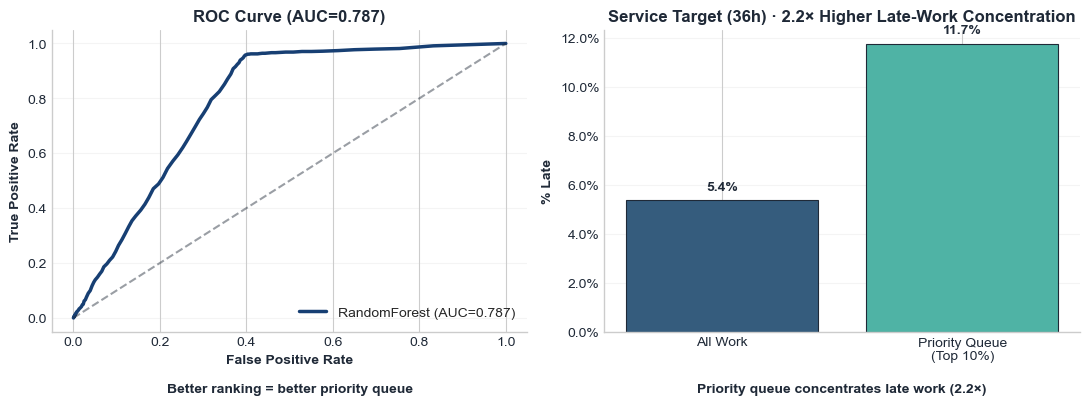

In [40]:
best_model = results_df.loc[0, "model"]
y_true_all = curves[best_model]["y_true"]
y_score_all = curves[best_model]["y_score"]
late_all = curves[best_model]["late_flag"]

fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
auc = roc_auc_score(y_true_all, y_score_all)

baseline = float(late_all.mean())
top10 = float(top_k_precision(late_all, y_score_all, top_frac=QUEUE_PCT))
lift = (top10 / baseline) if baseline > 0 else float("nan")

# Brand colors
slate = "#1F2937"
deep_blue = "#173F73"
brand_blue = "#355C7D"
teal = "#4FB3A5"
light_teal = "#CFEDE8"

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# ROC
ax[0].plot(
    fpr,
    tpr,
    color=deep_blue,
    linewidth=2.5,
    label=f"{best_model} (AUC={auc:.3f})"
)

ax[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=slate,
    alpha=0.45,
    linewidth=1.5
)

ax[0].set_xlabel("False Positive Rate", fontweight="bold", color=slate)
ax[0].set_ylabel("True Positive Rate", fontweight="bold", color=slate)
ax[0].set_title(f"ROC Curve (AUC={auc:.3f})", fontweight="bold", color=slate)
ax[0].legend(loc="lower right", frameon=False)

ax[0].text(
    0.5,
    -0.20,
    "Better ranking = better priority queue",
    transform=ax[0].transAxes,
    ha="center",
    fontweight="bold",
    color=slate
)

# SLA lift
bars = ax[1].bar(
    ["All Work", f"Priority Queue\n(Top {int(QUEUE_PCT*100)}%)"],
    [baseline, top10],
    color=[brand_blue, teal],
    edgecolor=slate,
    linewidth=0.8
)

ax[1].set_ylabel("% Late", fontweight="bold", color=slate)
ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))

ax[1].set_title(
    f"Service Target ({SLA_HOURS:.0f}h) · {lift:.1f}× Higher Late-Work Concentration",
    fontweight="bold",
    color=slate
)

for bar in bars:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.003,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=slate
    )

ax[1].text(
    0.5,
    -0.20,
    f"Priority queue concentrates late work ({lift:.1f}×)",
    transform=ax[1].transAxes,
    ha="center",
    fontweight="bold",
    color=slate
)

# Clean styling
for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(colors=slate)
    a.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

## Priority Queue Confusion Matrix

The model is not used as a simple yes/no classifier. Instead, it ranks work by predicted risk and routes the highest-risk 10% into a priority queue.

This confusion matrix evaluates that operational decision:

- **Priority Queue** = top 10% highest-risk work items
- **Normal Queue** = remaining 90%
- **Late** = missed the derived service target

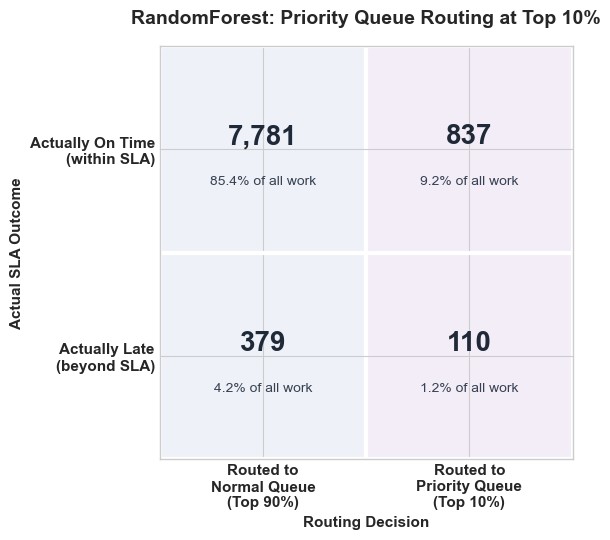

In [41]:
# Operational threshold: route the top 10% highest-risk items
risk_threshold = np.quantile(y_score_all, 1 - QUEUE_PCT)

priority_queue = (y_score_all >= risk_threshold).astype(int)

cm = confusion_matrix(
    late_all,
    priority_queue,
    labels=[0, 1]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual On Time", "Actual Late"],
    columns=["Normal Queue", "Priority Queue"]
)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Muted background shading by routing decision
bg = np.array([[0, 1], [0, 1]])
cmap = ListedColormap(["#EEF2F8", "#F3EDF8"])  # muted blue, muted purple

ax.imshow(bg, cmap=cmap, vmin=0, vmax=1)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Routed to\nNormal Queue\n(Top 90%)", "Routed to\nPriority Queue\n(Top 10%)"],
    fontsize=11,
    fontweight="bold"
)

ax.set_yticklabels(
    ["Actually On Time\n(within SLA)", "Actually Late\n(beyond SLA)"],
    fontsize=11,
    fontweight="bold"
)

total = cm.sum()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = count / total
        
        ax.text(
            j,
            i - 0.06,
            f"{count:,}",
            ha="center",
            va="center",
            fontsize=20,
            fontweight="bold",
            color="#1F2937"
        )
        
        ax.text(
            j,
            i + 0.16,
            f"{pct:.1%} of all work",
            ha="center",
            va="center",
            fontsize=10,
            color="#374151"
        )

ax.set_title(
    f"{best_model}: Priority Queue Routing at Top {int(QUEUE_PCT*100)}%",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Routing Decision", fontsize=11, fontweight="bold")
ax.set_ylabel("Actual SLA Outcome", fontsize=11, fontweight="bold")

# Light gridlines between cells
ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.show()

### Interpretation

A small priority queue captured a disproportionate share of future delays. The delay rate within the priority queue was more than twice the baseline delay rate, demonstrating that risk scores concentrated elevated-risk work into a smaller review population.

## Top-10% Routing Summary
The confusion matrix translates model performance into the operational decision being tested: whether a small priority queue can capture a disproportionate share of late work.

Rather than optimizing overall accuracy, this workflow evaluates whether predicted risk scores can concentrate future SLA misses into a manageable review queue.

In [42]:
total_items = len(late_all)
routed_items = int(priority_queue.sum())
late_items = int(late_all.sum())

late_routed = int(((late_all == 1) & (priority_queue == 1)).sum())
on_time_routed = int(((late_all == 0) & (priority_queue == 1)).sum())

capture_rate = late_routed / late_items if late_items > 0 else np.nan
queue_late_rate = late_routed / routed_items if routed_items > 0 else np.nan
baseline_late_rate = late_items / total_items if total_items > 0 else np.nan
lift = queue_late_rate / baseline_late_rate if baseline_late_rate > 0 else np.nan

routing_summary = pd.DataFrame(
    {
        "Metric": [
            "Total work items",
            "Items routed to priority queue",
            "Late items captured in priority queue",
            "Late-item capture rate",
            "Baseline late rate",
            "Priority queue late rate",
            "Late-rate lift"
        ],
        "Value": [
            f"{total_items:,}",
            f"{routed_items:,} ({routed_items / total_items:.1%})",
            f"{late_routed:,} of {late_items:,}",
            f"{capture_rate:.1%}",
            f"{baseline_late_rate:.1%}",
            f"{queue_late_rate:.1%}",
            f"{lift:.1f}x"
        ]
    }
)

display(routing_summary)

,Metric,Value
0,Total work items,"9,107"
1,Items routed to priority queue,947 (10.4%)
2,Late items captured in priority queue,110 of 489
3,Late-item capture rate,22.5%
4,Baseline late rate,5.4%
5,Priority queue late rate,11.6%
6,Late-rate lift,2.2x


## Limitations

- Uses simulated operational data rather than production records.
- Automation impacts are incorporated through documented simulation assumptions.
- Results demonstrate methodology and decision framing rather than estimate real-world ROI.
- Risk scores are intended to support prioritization decisions, not automated workflow actions.

## Operational Decision

This model produces an **intake risk score** to prioritize work and support **time-based service targets**.

### Stakeholder Interpretation

The model **ranks incoming work by predicted cycle-time risk**. In this workflow, the **top 10% highest-risk items** are routed to a priority queue for earlier review, staffing adjustment, or instrument rebalancing.

The key operational question is **not whether the model predicts every late item correctly**. The question is whether a **small review queue captures more late work than random selection**, allowing limited operational resources to be focused where they are most likely to matter.

### Technical Interpretation

This classification problem is intentionally treated as a **ranking problem** because the high-risk class represents a relatively small proportion of total work.

**Overall accuracy is not emphasized**, since most work items are not late and accuracy can therefore provide a misleading picture of model usefulness.

Model performance is evaluated using:

- **Instrument-held-out cross-validation**
- **Fold-specific P90 target labels**
- **Predicted probabilities (risk scores)**
- **Top-10% routing precision**
- **Late-rate lift**
- **Confusion matrix at the operational routing threshold**

To reduce information leakage, **rolling workload features are shifted by one day**, ensuring that only information available at the time of routing is used for prediction.